# Gate Feature Cache & Parameter Sweeps Dashboard

This notebook guides you through running the gate-level feature cache pre-processing, performing parameter sweeps, and visualizing the resulting tracklet stability.

---
## Step 1: Run the Caching and Parameter Sweep Scripts

Let's run the scripts to precalculate the gate-level feature cache, execute the regional cluster discovery, and run the parameter sweeps.

In [1]:
# Build gate cache (run only once or when raw data changes)
!python ../scripts/build_gate_feature_cache.py ../cases/k7uaz_20260322/config.yaml --primary-sites

# Run cluster discovery using the gate cache
!python ../scripts/discover_regional_balloon_like_clusters.py ../cases/k7uaz_20260322/config.yaml --primary-sites --use-gate-cache --overwrite

# Run parameter sweep on 144 configurations using the gate cache
!python ../scripts/run_discovery_parameter_sweep.py ../cases/k7uaz_20260322/config.yaml --primary-sites

Caching gates for active sites: KEMX, KIWA
Building cache per site:   0%|                           | 0/2 [00:00<?, ?it/s]
## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Building cache per site: 100%|███████████████████| 2/2 [01:53<00:00, 56.71s/it]
Updated gate cache inventory at ../cases/k7uaz_20260322/cache/gates/gate_cache_inventory.csv with 66 new/updated records.
Discovering clusters for active sites: KEMX, KIWA

## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
#

## Step 2: Load the Results

Let's load the generated sweep combinations and tracklet stability metrics into pandas DataFrames.

In [2]:
from pathlib import Path
import pandas as pd

sweep_csv = Path('../cases/k7uaz_20260322/outputs/sweeps/discovery_parameter_sweep.csv')
stability_csv = Path('../cases/k7uaz_20260322/outputs/sweeps/tracklet_stability.csv')

if sweep_csv.exists() and stability_csv.exists():
    sweep_df = pd.read_csv(sweep_csv)
    stability_df = pd.read_csv(stability_csv)
    print(f"Loaded {len(sweep_df)} sweep configurations.")
    print(f"Loaded {len(stability_df)} unique candidate tracklets.")
else:
    print("Warning: Sweep files not found! Please run the scripts in Step 1 first.")

Loaded 288 sweep configurations.
Loaded 6 unique candidate tracklets.


## Step 3: Visualize Parameter Sweep Sensitivity

Let's plot how the number of clusters and tracklets varies with the altitude padding and horizontal corridor width.

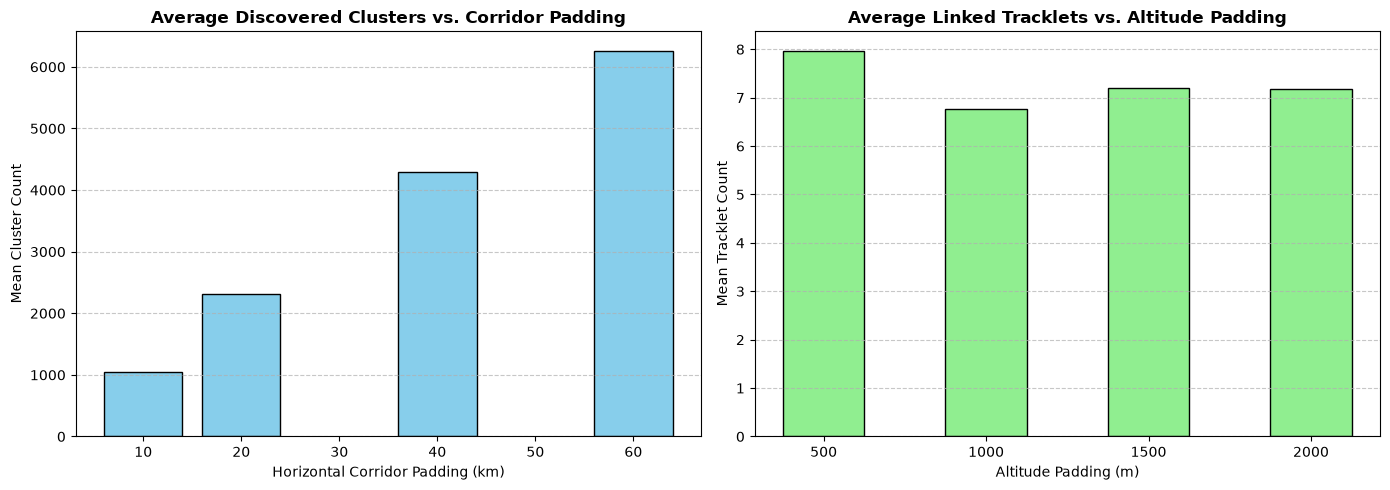

In [3]:
import matplotlib.pyplot as plt
import numpy as np

if sweep_csv.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Clusters by Horizontal Corridor Padding
    corridors = sorted(sweep_df['horizontal_corridor_padding_km'].unique())
    mean_clusters = [sweep_df[sweep_df['horizontal_corridor_padding_km'] == c]['n_clusters'].mean() for c in corridors]
    axes[0].bar(corridors, mean_clusters, color='skyblue', edgecolor='black', width=8)
    axes[0].set_title('Average Discovered Clusters vs. Corridor Padding', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Horizontal Corridor Padding (km)', fontsize=10)
    axes[0].set_ylabel('Mean Cluster Count', fontsize=10)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # 2. Tracklets by Altitude Padding
    paddings = sorted(sweep_df['altitude_padding_m'].unique())
    mean_tracklets = [sweep_df[sweep_df['altitude_padding_m'] == p]['n_tracklets'].mean() for p in paddings]
    axes[1].bar([str(p) for p in paddings], mean_tracklets, color='lightgreen', edgecolor='black', width=0.5)
    axes[1].set_title('Average Linked Tracklets vs. Altitude Padding', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Altitude Padding (m)', fontsize=10)
    axes[1].set_ylabel('Mean Tracklet Count', fontsize=10)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

## Step 4: Tracklet Stability Distribution

A candidate tracklet is considered **stable** if it is consistently discovered across various sweep configurations (high detection fraction). Let's plot the distribution of tracklet stability labels.

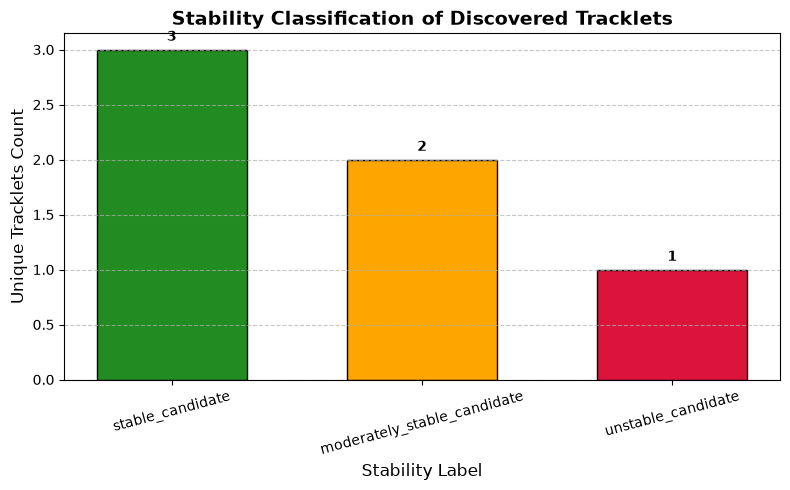

In [4]:
if stability_csv.exists():
    stability_counts = stability_df['stability_label'].value_counts()
    
    plt.figure(figsize=(8, 5))
    
    # Map colors to labels
    color_map = {
        'stable_candidate': 'forestgreen',
        'moderately_stable_candidate': 'orange',
        'unstable_candidate': 'crimson'
    }
    bar_colors = [color_map.get(label, 'grey') for label in stability_counts.index]
    
    bars = plt.bar(stability_counts.index, stability_counts.values, color=bar_colors, edgecolor='black', width=0.6)
    
    plt.title('Stability Classification of Discovered Tracklets', fontsize=14, fontweight='bold')
    plt.xlabel('Stability Label', fontsize=12)
    plt.ylabel('Unique Tracklets Count', fontsize=12)
    plt.xticks(rotation=15)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add values on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, int(yval), ha='center', va='bottom', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

## Step 5: Inspection of Stable Candidates

Here are the most robust candidate tracklets that survived different sweep parameter choices.

In [5]:
if stability_csv.exists():
    # Sort by detection fraction descending
    stable_candidates = stability_df.sort_values(by='detection_fraction', ascending=False)
    
    # Display top 10
    display(stable_candidates.head(10))

,tracklet_signature,radar_site,start_time_utc,end_time_utc,n_points_median,duration_min_median,detection_count,detection_fraction,stability_label
5,KIWA_2026-03-22T19:26:39Z_2026-03-22T20:37:50Z,KIWA,2026-03-22T19:26:39Z,2026-03-22T20:37:50Z,6.0,35.6,1440,10.0000,stable_candidate
0,KEMX_2026-03-22T18:49:37Z_2026-03-22T22:54:53Z,KEMX,2026-03-22T18:49:37Z,2026-03-22T22:54:53Z,14.0,134.5,280,1.9444,stable_candidate
1,KEMX_2026-03-22T18:49:37Z_2026-03-22T21:31:58Z,KEMX,2026-03-22T18:49:37Z,2026-03-22T21:31:58Z,12.0,120.3,207,1.4375,stable_candidate
4,KEMX_2026-03-22T19:39:14Z_2026-03-22T20:14:42Z,KEMX,2026-03-22T19:39:14Z,2026-03-22T20:14:42Z,6.0,35.5,84,0.5833,moderately_stable_candidate
2,KEMX_2026-03-22T19:32:08Z_2026-03-22T22:47:59Z,KEMX,2026-03-22T19:32:08Z,2026-03-22T22:47:59Z,7.0,56.5,72,0.5000,moderately_stable_candidate
3,KEMX_2026-03-22T18:49:37Z_2026-03-22T22:34:11Z,KEMX,2026-03-22T18:49:37Z,2026-03-22T22:34:11Z,14.0,155.4,14,0.0972,unstable_candidate
